# 01. Exploración inicial del dataset IQ-OTH/NCCD

Este notebook realiza el análisis inicial del dataset usado en el proyecto de **segmentación/clasificación de imágenes médicas de TC pulmonar**.

El objetivo de esta fase es comprobar la estructura real del dataset, separar correctamente las imágenes etiquetadas, estudiar la distribución de clases y analizar las características técnicas de las imágenes antes de entrenar modelos.

> Nota metodológica: la carpeta `Test cases` no se trata como una cuarta clase porque no corresponde a una categoría diagnóstica supervisada. El problema se plantea con tres clases: `normal`, `benign` y `malignant`.

## 0. Configuración inicial

Se importan las librerías necesarias, se fija una semilla para reproducibilidad y se descarga el dataset desde KaggleHub.

In [2]:
!pip install kagglehub -q

import random
import math
import hashlib
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
DATASET_PATH = Path(path)

if Path("/kaggle/working").exists():
    processed_path = Path("/kaggle/working/processed")
elif Path("/content").exists():
    processed_path = Path("/content/processed")
else:
    processed_path = Path("../data/processed")

processed_path.mkdir(parents=True, exist_ok=True)

print("Ruta del dataset:", DATASET_PATH)
print("¿Existe?", DATASET_PATH.exists())
print("Carpeta de salida:", processed_path)

100%|████████████████████████████████████████████████████████████████████████████████| 199M/199M [07:43<00:00, 450kB/s]

Extracting files...


Ruta del dataset: C:\Users\Usuario\.cache\kagglehub\datasets\adityamahimkar\iqothnccd-lung-cancer-dataset\versions\2
¿Existe? True
Carpeta de salida: ..\data\processed


## 1. Construcción del índice de imágenes

Primero se localizan las carpetas que contienen imágenes y se construye un DataFrame con la ruta, el nombre de archivo y la carpeta original de cada muestra.

In [3]:
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
folders_with_images = []

for folder in DATASET_PATH.rglob("*"):
    if folder.is_dir():
        image_files = [
            file for file in folder.iterdir()
            if file.is_file() and file.suffix.lower() in image_extensions
        ]
        if len(image_files) > 0:
            folders_with_images.append((folder, len(image_files)))

print("Carpetas con imágenes encontradas:")
for folder, count in folders_with_images:
    print(f"{folder} -> {count} imágenes")

Carpetas con imágenes encontradas:
C:\Users\Usuario\.cache\kagglehub\datasets\adityamahimkar\iqothnccd-lung-cancer-dataset\versions\2\Test cases -> 197 imágenes
C:\Users\Usuario\.cache\kagglehub\datasets\adityamahimkar\iqothnccd-lung-cancer-dataset\versions\2\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Bengin cases -> 120 imágenes
C:\Users\Usuario\.cache\kagglehub\datasets\adityamahimkar\iqothnccd-lung-cancer-dataset\versions\2\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Malignant cases -> 561 imágenes
C:\Users\Usuario\.cache\kagglehub\datasets\adityamahimkar\iqothnccd-lung-cancer-dataset\versions\2\The IQ-OTHNCCD lung cancer dataset\The IQ-OTHNCCD lung cancer dataset\Normal cases -> 416 imágenes


In [4]:
class_dirs = [folder for folder, _ in folders_with_images]

data = []

for class_dir in class_dirs:
    class_name = class_dir.name
    for img_path in class_dir.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            data.append({
                "path": str(img_path),
                "filename": img_path.name,
                "original_class": class_name
            })

df = pd.DataFrame(data)

print("Número total de imágenes encontradas:", len(df))
df.head()

Número total de imágenes encontradas: 1294


,path,filename,original_class
0,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,000001_03_01_088.png,Test cases
1,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,000017_02_01_016.png,Test cases
2,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,000019_01_01_021.png,Test cases
3,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,000019_02_01_025.png,Test cases
4,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,000019_03_01_025.png,Test cases


### 1.1. Normalización de clases

Se normalizan los nombres de carpeta para obtener etiquetas consistentes. La carpeta `Test cases` se marca como `unlabeled_test`, ya que no representa una clase diagnóstica comparable con `normal`, `benign` o `malignant`.

In [5]:
def normalize_class_name(class_name):
    name = class_name.lower()

    if "normal" in name:
        return "normal"
    elif "malignant" in name:
        return "malignant"
    elif "bengin" in name or "benign" in name:
        return "benign"
    elif "test" in name:
        return "unlabeled_test"
    else:
        return "unknown"


df["class"] = df["original_class"].apply(normalize_class_name)

print("Distribución inicial tras normalizar clases:")
print(df["class"].value_counts())

Distribución inicial tras normalizar clases:
class
malignant         561
normal            416
unlabeled_test    197
benign            120
Name: count, dtype: int64


In [7]:
labeled_df = df[df["class"].isin(["normal", "benign", "malignant"])].copy()
unlabeled_test_df = df[df["class"] == "unlabeled_test"].copy()

print("Imágenes etiquetadas:", len(labeled_df))
print("Imágenes de test sin etiqueta:", len(unlabeled_test_df))
print("Distribución del dataset etiquetado:")
print(labeled_df["class"].value_counts())

Imágenes etiquetadas: 1097
Imágenes de test sin etiqueta: 197
Distribución del dataset etiquetado:
class
malignant    561
normal       416
benign       120
Name: count, dtype: int64


### 1.2. Distribución de clases

Se analiza el número de imágenes por clase dentro del conjunto etiquetado. Esta información será importante para decidir las métricas de evaluación y posibles estrategias contra el desbalanceo.

class
malignant    561
normal       416
benign       120
Name: count, dtype: int64


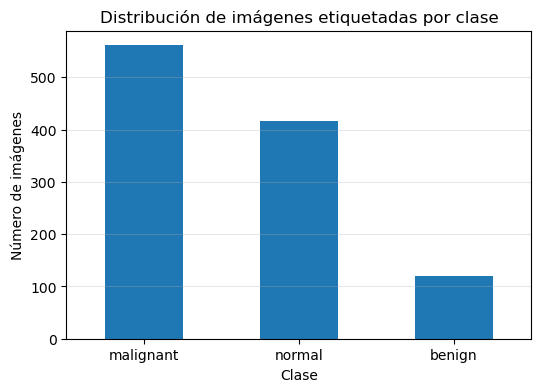

In [8]:
class_counts = labeled_df["class"].value_counts()

print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Distribución de imágenes etiquetadas por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### 1.3. Guardado inicial de los índices

Se guardan tres archivos: el dataset completo, el subconjunto etiquetado y el conjunto `Test cases` sin etiqueta. A partir de este punto, el entrenamiento supervisado usará únicamente `labeled_df`.

In [9]:
df.to_csv(processed_path / "dataset_full.csv", index=False)
labeled_df.to_csv(processed_path / "dataset_labeled.csv", index=False)
unlabeled_test_df.to_csv(processed_path / "dataset_unlabeled_test.csv", index=False)

print("Archivos guardados en:", processed_path)

Archivos guardados en: ..\data\processed


## 2. Partición train / validation / test

Se realiza una partición estratificada del conjunto etiquetado. El conjunto de prueba se reservará para la evaluación final, no para ajustar hiperparámetros.

In [10]:
train_df, temp_df = train_test_split(
    labeled_df,
    test_size=0.30,
    stratify=labeled_df["class"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 767
Validation: 165
Test: 165


In [11]:
def split_distribution(split_df, split_name):
    counts = split_df["class"].value_counts().sort_index()
    proportions = split_df["class"].value_counts(normalize=True).sort_index()
    return pd.DataFrame({
        "split": split_name,
        "class": counts.index,
        "count": counts.values,
        "proportion": proportions.values
    })

split_summary = pd.concat([
    split_distribution(train_df, "train"),
    split_distribution(val_df, "validation"),
    split_distribution(test_df, "test")
], ignore_index=True)

split_summary

,split,class,count,proportion
0,train,benign,84,0.109518
1,train,malignant,392,0.511082
2,train,normal,291,0.379400
3,validation,benign,18,0.109091
4,validation,malignant,84,0.509091
5,validation,normal,63,0.381818
6,test,benign,18,0.109091
7,test,malignant,85,0.515152
8,test,normal,62,0.375758


In [12]:
train_df.to_csv(processed_path / "train.csv", index=False)
val_df.to_csv(processed_path / "val.csv", index=False)
test_df.to_csv(processed_path / "test.csv", index=False)

print("Particiones guardadas correctamente.")

Particiones guardadas correctamente.


## 3. Análisis técnico de las imágenes

Se estudian la anchura, altura y modo de color de cada imagen etiquetada. Esto permite justificar el redimensionamiento común y comprobar si existen diferencias técnicas asociadas a alguna clase.

In [13]:
image_info = []

for _, row in labeled_df.iterrows():
    img_path = row["path"]
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode
        image_info.append({
            "path": img_path,
            "width": width,
            "height": height,
            "mode": mode
        })
    except Exception as e:
        print("Error leyendo la imagen:", img_path)
        print("Error:", e)

image_info_df = pd.DataFrame(image_info)

# Evita duplicar columnas si la celda se reejecuta parcialmente.
labeled_df = labeled_df.drop(columns=["width", "height", "mode"], errors="ignore")
labeled_df = labeled_df.merge(image_info_df, on="path", how="left")

labeled_df.head()

,path,filename,original_class,class,width,height,mode
0,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Bengin case (1).jpg,Bengin cases,benign,512,512,RGB
1,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Bengin case (10).jpg,Bengin cases,benign,512,512,RGB
2,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Bengin case (100).jpg,Bengin cases,benign,512,512,RGB
3,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Bengin case (101).jpg,Bengin cases,benign,512,512,RGB
4,C:\Users\Usuario\.cache\kagglehub\datasets\adi...,Bengin case (102).jpg,Bengin cases,benign,512,512,RGB


### 3.1. Resumen general de resoluciones

Se calcula un resumen estadístico de anchura y altura, junto con las resoluciones más frecuentes del dataset etiquetado.

In [14]:
print("Número de imágenes etiquetadas analizadas:", len(labeled_df))

print(" Resumen estadístico:")
display(labeled_df[["width", "height"]].describe())

print(" Resoluciones más frecuentes:")
display(labeled_df[["width", "height"]].value_counts().head(10))

Número de imágenes etiquetadas analizadas: 1097
 Resumen estadístico:


,width,height
count,1097.000000,1097.000000
mean,522.506837,511.736554
std,48.700955,6.361155
min,506.000000,331.000000
25%,512.000000,512.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,801.000000,512.000000


 Resoluciones más frecuentes:


width  height
512    512       1036
623    512         31
801    512         28
506    331          1
511    404          1
Name: count, dtype: int64

### 3.2. Modos de imagen

Las redes preentrenadas suelen esperar imágenes con tres canales. Por eso se comprueba si las imágenes están almacenadas en RGB, escala de grises u otro modo.

Modos de imagen encontrados:
mode
RGB    1097
Name: count, dtype: int64


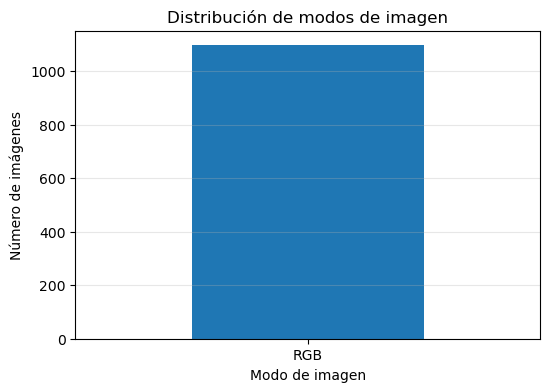

In [15]:
print("Modos de imagen encontrados:")
print(labeled_df["mode"].value_counts())

plt.figure(figsize=(6, 4))
labeled_df["mode"].value_counts().plot(kind="bar")
plt.title("Distribución de modos de imagen")
plt.xlabel("Modo de imagen")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### 3.3. Distribución de anchura, altura y relación entre dimensiones

Se representan las dimensiones de las imágenes para detectar posibles resoluciones atípicas.

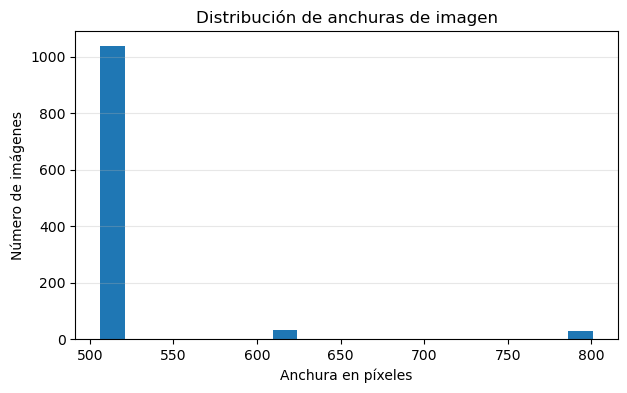

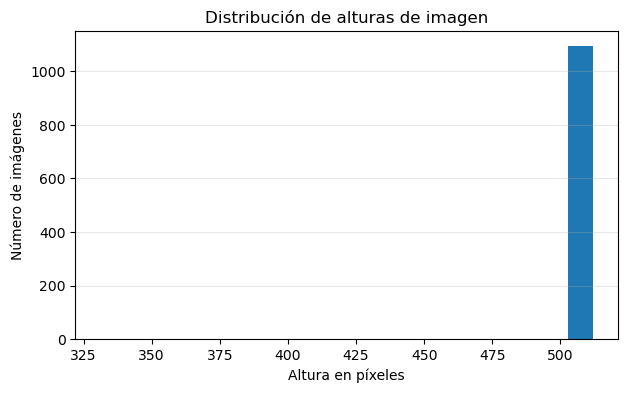

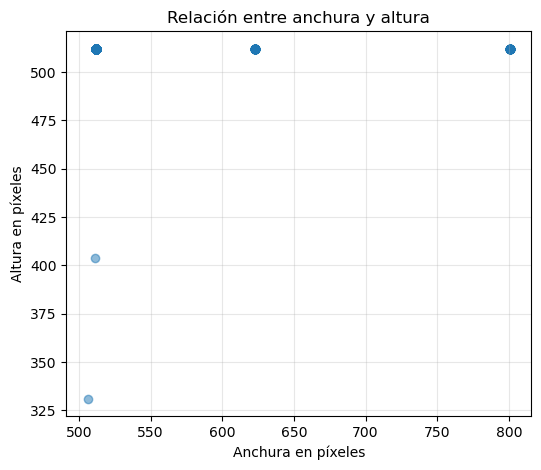

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(labeled_df["width"], bins=20)
plt.title("Distribución de anchuras de imagen")
plt.xlabel("Anchura en píxeles")
plt.ylabel("Número de imágenes")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(labeled_df["height"], bins=20)
plt.title("Distribución de alturas de imagen")
plt.xlabel("Altura en píxeles")
plt.ylabel("Número de imágenes")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(labeled_df["width"], labeled_df["height"], alpha=0.5)
plt.title("Relación entre anchura y altura")
plt.xlabel("Anchura en píxeles")
plt.ylabel("Altura en píxeles")
plt.grid(alpha=0.3)
plt.show()

### 3.4. Resolución por clase

Se comprueba si las resoluciones atípicas están repartidas de forma homogénea o si se concentran en una clase concreta.

width                                                            \
           count        mean        std    min    25%    50%    75%    max   
class                                                                        
benign     120.0  512.000000   0.000000  512.0  512.0  512.0  512.0  512.0   
malignant  561.0  532.556150  66.594274  511.0  512.0  512.0  512.0  801.0   
normal     416.0  511.985577   0.294174  506.0  512.0  512.0  512.0  512.0   

          height                                                           
           count        mean       std    min    25%    50%    75%    max  
class                                                                      
benign     120.0  512.000000  0.000000  512.0  512.0  512.0  512.0  512.0  
malignant  561.0  511.807487  4.559764  404.0  512.0  512.0  512.0  512.0  
normal     416.0  511.564904  8.874255  331.0  512.0  512.0  512.0  512.0

 Clase: benign
width  height
512    512       120
Name: count, dtype: int64
 Clase: malignant
width  height
512    512       501
623    512        31
801    512        28
511    404         1
Name: count, dtype: int64
 Clase: normal
width  height
512    512       415
506    331         1
Name: count, dtype: int64


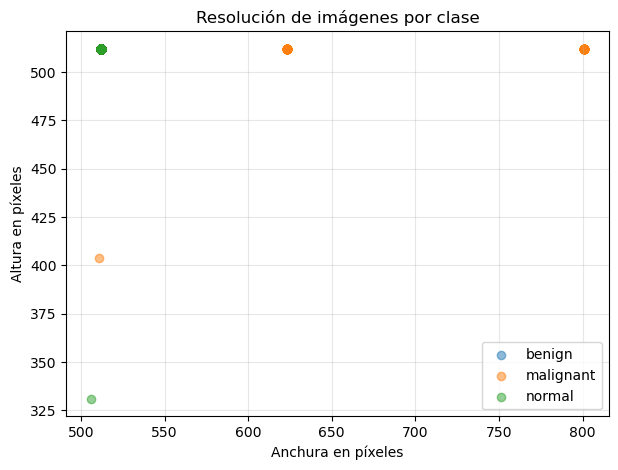

In [17]:
display(labeled_df.groupby("class")[["width", "height"]].describe())

for class_name in sorted(labeled_df["class"].unique()):
    print(f" Clase: {class_name}")
    print(labeled_df[labeled_df["class"] == class_name][["width", "height"]].value_counts().head(5))

plt.figure(figsize=(7, 5))
for class_name in sorted(labeled_df["class"].unique()):
    subset = labeled_df[labeled_df["class"] == class_name]
    plt.scatter(subset["width"], subset["height"], alpha=0.5, label=class_name)

plt.title("Resolución de imágenes por clase")
plt.xlabel("Anchura en píxeles")
plt.ylabel("Altura en píxeles")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.5. Comprobación de errores de lectura

Se comprueba si existen valores nulos en las columnas técnicas. Si aparecieran nulos, habría que revisar imágenes corruptas o incompatibles.

In [18]:
print("Valores nulos por columna:")
print(labeled_df[["width", "height", "mode"]].isnull().sum())

Valores nulos por columna:
width     0
height    0
mode      0
dtype: int64


## 4. Imágenes con resolución atípica

Se aíslan las imágenes cuya resolución no es 512x512. Este análisis es relevante porque las resoluciones atípicas podrían actuar como una pista artificial para el clasificador.

In [19]:
atypical_df = labeled_df[
    (labeled_df["width"] != 512) | (labeled_df["height"] != 512)
].copy()

print("Número de imágenes con resolución distinta de 512x512:", len(atypical_df))
display(atypical_df[["filename", "class", "width", "height", "path"]].head(20))

Número de imágenes con resolución distinta de 512x512: 61


,filename,class,width,height,path
210,Malignant case (180).jpg,malignant,511,404,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
233,Malignant case (200).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
234,Malignant case (201).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
235,Malignant case (202).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
236,Malignant case (203).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
237,Malignant case (204).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
238,Malignant case (205).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
239,Malignant case (206).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
240,Malignant case (207).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
241,Malignant case (208).jpg,malignant,801,512,C:\Users\Usuario\.cache\kagglehub\datasets\adi...


In [20]:
print("Imágenes atípicas por clase:")
print(atypical_df["class"].value_counts())

print("Resoluciones atípicas:")
print(atypical_df[["width", "height"]].value_counts())

Imágenes atípicas por clase:
class
malignant    60
normal        1
Name: count, dtype: int64
Resoluciones atípicas:
width  height
623    512       31
801    512       28
506    331        1
511    404        1
Name: count, dtype: int64


### 4.1. Visualización de ejemplos atípicos

Se muestran algunas imágenes con resolución distinta de 512x512 para comprobar visualmente si presentan encuadres, bordes o artefactos distintos.

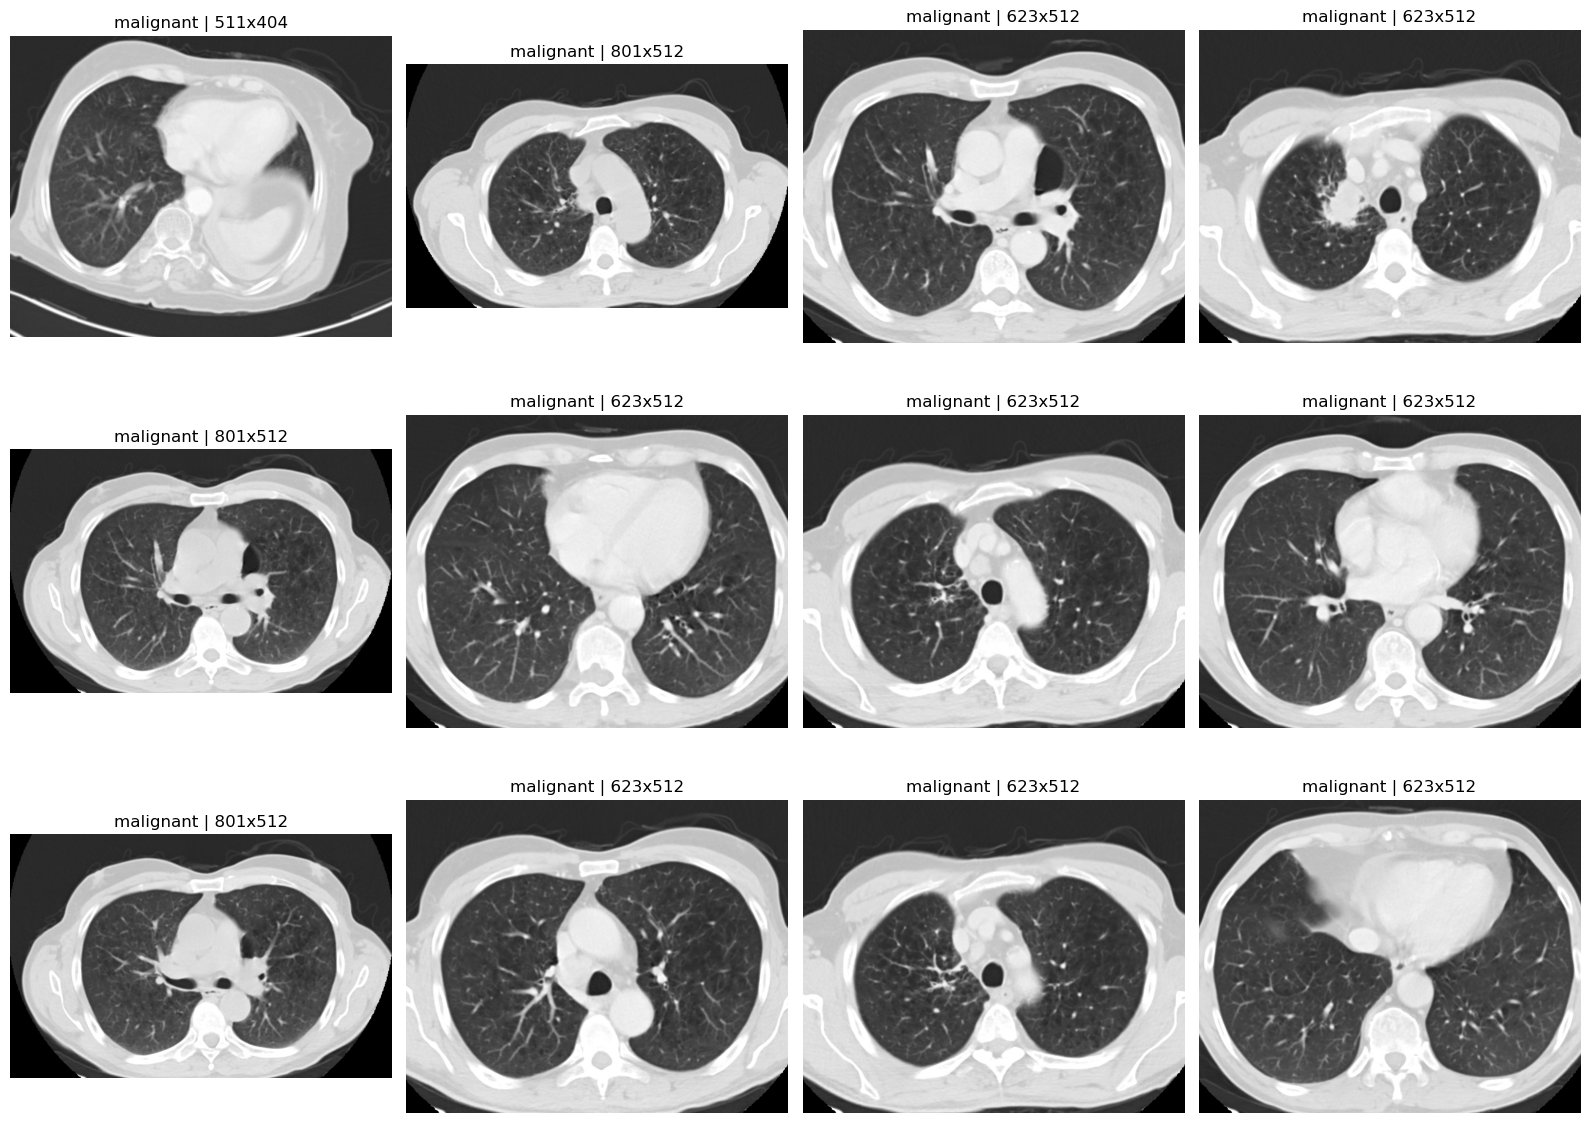

In [21]:
if len(atypical_df) > 0:
    sample_atypical = atypical_df.sample(
        n=min(12, len(atypical_df)),
        random_state=SEED
    )

    n = len(sample_atypical)
    cols = 4
    rows = math.ceil(n / cols)

    plt.figure(figsize=(16, 4 * rows))
    for i, (_, row) in enumerate(sample_atypical.iterrows()):
        img = Image.open(row["path"])
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"{row['class']} | {row['width']}x{row['height']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No se han encontrado imágenes atípicas.")

### 4.2. Decisión de preprocesamiento

El dataset es mayoritariamente homogéneo, pero las imágenes con resolución atípica se concentran sobre todo en la clase maligna. Por ello, antes de entrenar se aplicará un preprocesamiento común a todas las imágenes:

- conversión a RGB;
- redimensionamiento a 224x224 píxeles;
- normalización según la arquitectura usada.

Esta decisión no solo responde a los requisitos técnicos de los modelos preentrenados, sino también a la necesidad de reducir posibles sesgos por diferencias de resolución.

In [22]:
summary_resolution = pd.DataFrame({
    "Aspecto analizado": [
        "Total de imágenes etiquetadas",
        "Resolución dominante",
        "Imágenes 512x512",
        "Imágenes atípicas",
        "Imágenes atípicas malignas",
        "Imágenes atípicas normales",
        "Imágenes atípicas benignas",
        "Valores nulos detectados"
    ],
    "Resultado": [
        len(labeled_df),
        "512x512",
        int(((labeled_df["width"] == 512) & (labeled_df["height"] == 512)).sum()),
        len(atypical_df),
        int(atypical_df["class"].value_counts().get("malignant", 0)),
        int(atypical_df["class"].value_counts().get("normal", 0)),
        int(atypical_df["class"].value_counts().get("benign", 0)),
        int(labeled_df[["width", "height", "mode"]].isnull().sum().sum())
    ]
})

summary_resolution

,Aspecto analizado,Resultado
0,Total de imágenes etiquetadas,1097
1,Resolución dominante,512x512
2,Imágenes 512x512,1036
3,Imágenes atípicas,61
4,Imágenes atípicas malignas,60
5,Imágenes atípicas normales,1
6,Imágenes atípicas benignas,0
7,Valores nulos detectados,0


In [23]:
# Actualizar particiones con las columnas técnicas ya calculadas.
technical_cols = labeled_df[["path", "width", "height", "mode"]]

def add_image_metadata(split_df):
    split_df = split_df.drop(columns=["width", "height", "mode"], errors="ignore")
    return split_df.merge(technical_cols, on="path", how="left")

train_df = add_image_metadata(train_df)
val_df = add_image_metadata(val_df)
test_df = add_image_metadata(test_df)

# Guardado final de archivos procesados.
labeled_df.to_csv(processed_path / "dataset_labeled.csv", index=False)
atypical_df.to_csv(processed_path / "atypical_images.csv", index=False)
summary_resolution.to_csv(processed_path / "summary_resolution.csv", index=False)
train_df.to_csv(processed_path / "train.csv", index=False)
val_df.to_csv(processed_path / "val.csv", index=False)
test_df.to_csv(processed_path / "test.csv", index=False)

print("Archivos finales guardados en:", processed_path)

Archivos finales guardados en: ..\data\processed


## 5. Visualización de ejemplos por clase

Se visualizan ejemplos representativos de cada clase diagnóstica del conjunto etiquetado. Esta inspección permite detectar posibles diferencias visuales, artefactos, bordes, marcas externas o problemas de calidad que puedan afectar al entrenamiento de los modelos.

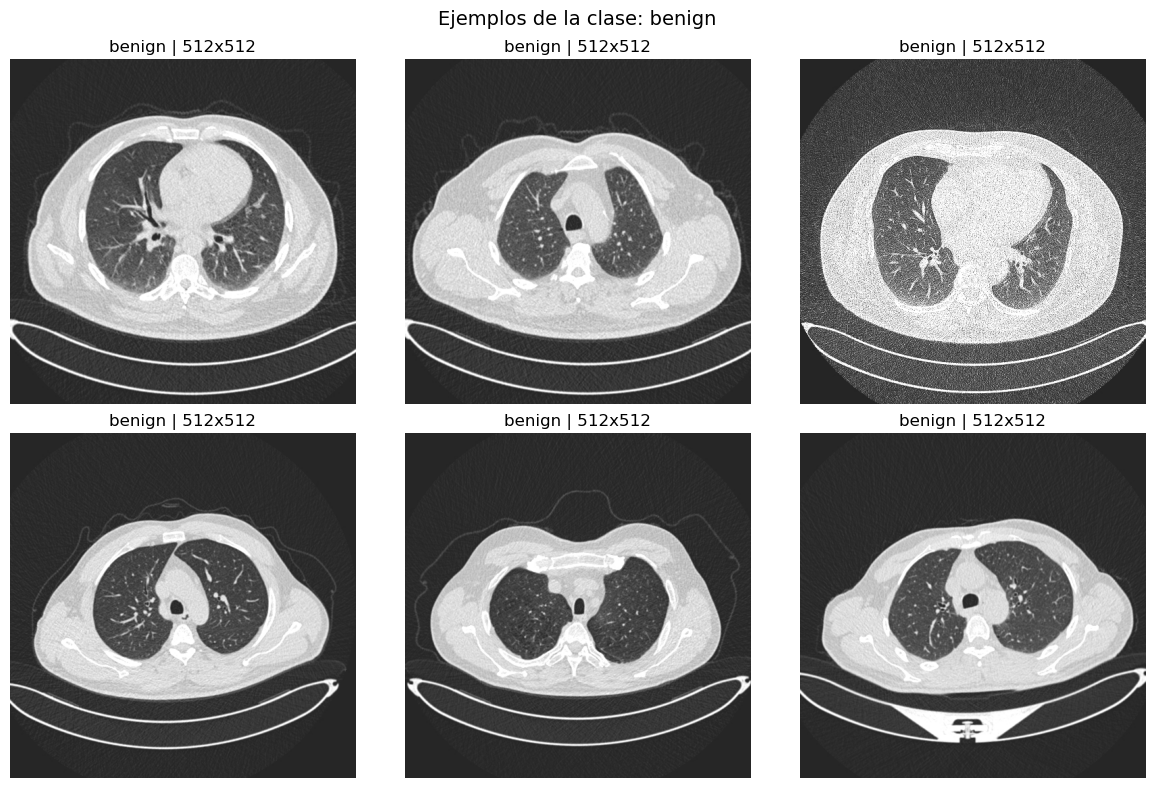

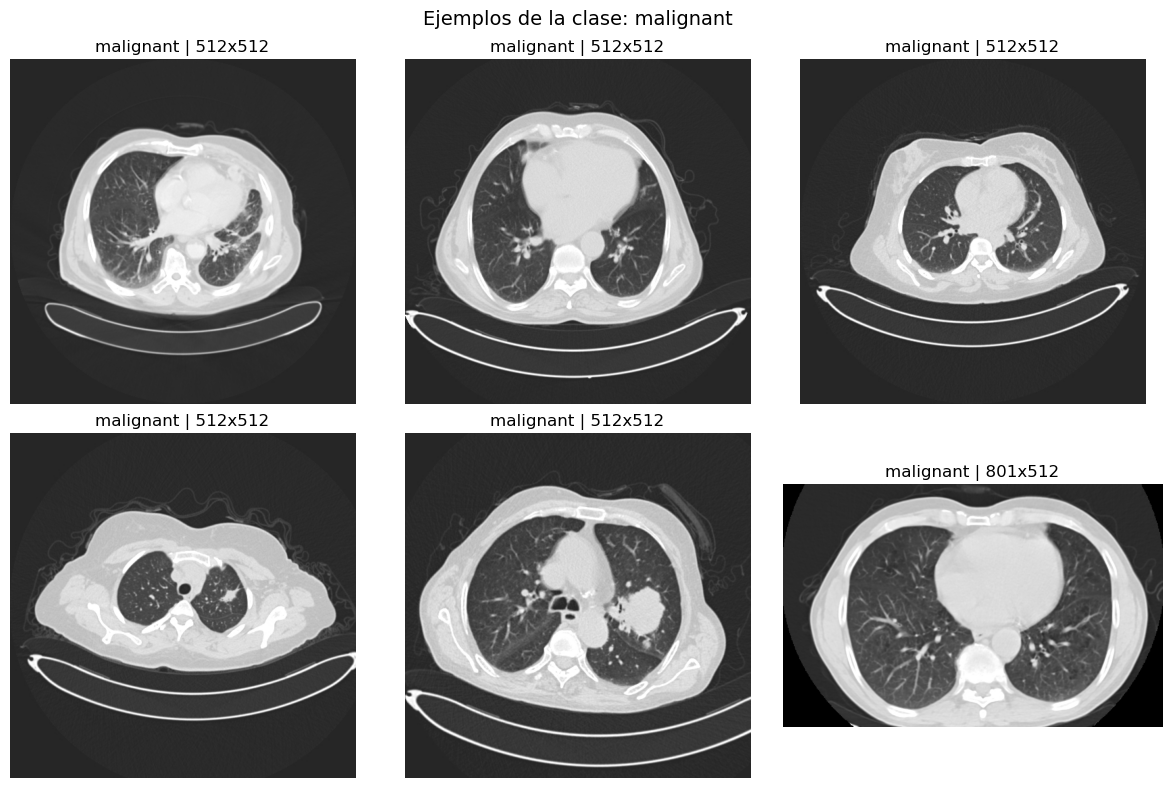

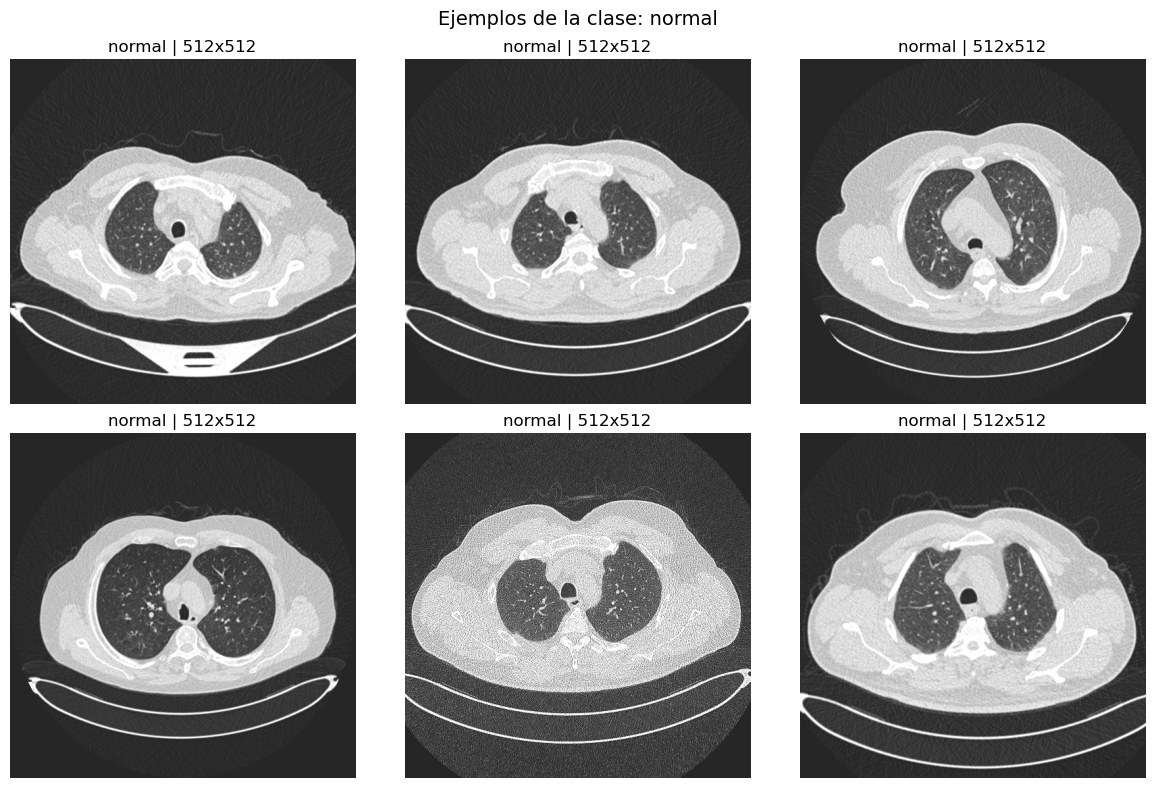

In [24]:
figures_path = processed_path / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

def show_examples_by_class(df, n=6, random_state=SEED, save_figures=True):
    for class_name in sorted(df["class"].unique()):
        subset = df[df["class"] == class_name].sample(
            n=min(n, len(df[df["class"] == class_name])),
            random_state=random_state
        )

        cols = 3
        rows = math.ceil(len(subset) / cols)

        plt.figure(figsize=(12, 4 * rows))

        for i, (_, row) in enumerate(subset.iterrows()):
            img = Image.open(row["path"]).convert("RGB")

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f"{row['class']} | {row['width']}x{row['height']}")
            plt.axis("off")

        plt.suptitle(f"Ejemplos de la clase: {class_name}", fontsize=14)
        plt.tight_layout()

        if save_figures:
            plt.savefig(
                figures_path / f"examples_{class_name}.png",
                dpi=150,
                bbox_inches="tight"
            )

        plt.show()

show_examples_by_class(labeled_df, n=6)

La inspección visual permite confirmar que las imágenes corresponden a cortes axiales de TC pulmonar. También sirve para comprobar si existen diferencias evidentes de contraste, encuadre o presencia de zonas negras entre clases.

Estas figuras se guardan automáticamente para poder utilizarlas posteriormente en la memoria del proyecto.

## 6. Comprobación de duplicados exactos

Se comprueba la existencia de imágenes duplicadas exactas mediante el cálculo de un hash MD5 para cada archivo. Esta comprobación es importante porque si una misma imagen aparece tanto en entrenamiento como en prueba, el rendimiento del modelo podría quedar artificialmente sobreestimado.

In [25]:
def calculate_file_hash(path, chunk_size=8192):
    hasher = hashlib.md5()

    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            hasher.update(chunk)

    return hasher.hexdigest()


labeled_df["file_hash"] = labeled_df["path"].apply(calculate_file_hash)

duplicates_df = labeled_df[
    labeled_df.duplicated("file_hash", keep=False)
].sort_values(["file_hash", "class", "filename"])

num_duplicate_images = len(duplicates_df)
num_duplicate_groups = duplicates_df["file_hash"].nunique()

print("Número de imágenes duplicadas exactas:", num_duplicate_images)
print("Número de grupos de duplicados:", num_duplicate_groups)

duplicates_df[["filename", "class", "width", "height", "file_hash", "path"]].head(20)

Número de imágenes duplicadas exactas: 86
Número de grupos de duplicados: 43


,filename,class,width,height,file_hash,path
781,Normal case (19).jpg,normal,512,512,01999c7651f123040a7e961a635b0264,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
1030,Normal case (413).jpg,normal,512,512,01999c7651f123040a7e961a635b0264,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
17,Bengin case (114).jpg,benign,512,512,01da37fceb8444d1d35204fe202073da,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
18,Bengin case (115).jpg,benign,512,512,01da37fceb8444d1d35204fe202073da,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
81,Bengin case (64).jpg,benign,512,512,072e07b5986c5f1c04a74bb6d1ff45db,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
82,Bengin case (65).jpg,benign,512,512,072e07b5986c5f1c04a74bb6d1ff45db,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
35,Bengin case (22).jpg,benign,512,512,092589d7fbdb7b330150cc2917f75244,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
36,Bengin case (23).jpg,benign,512,512,092589d7fbdb7b330150cc2917f75244,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
165,Malignant case (14).jpg,malignant,512,512,0fb9ea60c4be3dd91f1f712a1d8c8797,C:\Users\Usuario\.cache\kagglehub\datasets\adi...
174,Malignant case (148).jpg,malignant,512,512,0fb9ea60c4be3dd91f1f712a1d8c8797,C:\Users\Usuario\.cache\kagglehub\datasets\adi...


### 6.1. Duplicados con etiquetas contradictorias

Además de detectar duplicados exactos, se comprueba si una misma imagen aparece asociada a más de una clase. Este caso sería especialmente problemático porque indicaría una posible inconsistencia de etiquetado.

In [26]:
hash_class_counts = labeled_df.groupby("file_hash")["class"].nunique()
conflicting_hashes = hash_class_counts[hash_class_counts > 1].index.tolist()

conflicting_duplicates_df = labeled_df[
    labeled_df["file_hash"].isin(conflicting_hashes)
].sort_values(["file_hash", "class", "filename"])

print("Número de hashes con etiquetas contradictorias:", len(conflicting_hashes))
display(conflicting_duplicates_df[["filename", "class", "width", "height", "file_hash", "path"]].head(20))

Número de hashes con etiquetas contradictorias: 0


,filename,class,width,height,file_hash,path


### 6.2. Creación del dataset final

Si existen duplicados exactos dentro de la misma clase, se conserva una única copia para evitar filtraciones entre entrenamiento y prueba. Si existieran duplicados exactos con etiquetas contradictorias, se eliminarían del conjunto final por posible ruido de etiquetado.

In [27]:
# Eliminar posibles duplicados con etiquetas contradictorias
if len(conflicting_hashes) > 0:
    labeled_no_conflicts_df = labeled_df[
        ~labeled_df["file_hash"].isin(conflicting_hashes)
    ].copy()
else:
    labeled_no_conflicts_df = labeled_df.copy()

# Mantener una sola copia de duplicados exactos restantes
labeled_final_df = labeled_no_conflicts_df.drop_duplicates(
    subset="file_hash",
    keep="first"
).copy()

labeled_final_df = labeled_final_df.reset_index(drop=True)

duplicates_summary = pd.DataFrame({
    "Aspecto": [
        "Imágenes etiquetadas originales",
        "Imágenes duplicadas exactas",
        "Grupos de duplicados exactos",
        "Hashes con etiquetas contradictorias",
        "Imágenes finales tras limpieza"
    ],
    "Valor": [
        len(labeled_df),
        num_duplicate_images,
        num_duplicate_groups,
        len(conflicting_hashes),
        len(labeled_final_df)
    ]
})

display(duplicates_summary)

print("\nDistribución final por clase:")
print(labeled_final_df["class"].value_counts())

,Aspecto,Valor
0,Imágenes etiquetadas originales,1097
1,Imágenes duplicadas exactas,86
2,Grupos de duplicados exactos,43
3,Hashes con etiquetas contradictorias,0
4,Imágenes finales tras limpieza,1054



Distribución final por clase:
class
malignant    547
normal       405
benign       102
Name: count, dtype: int64


In [28]:
duplicates_df.to_csv(processed_path / "duplicate_images.csv", index=False)
conflicting_duplicates_df.to_csv(processed_path / "conflicting_duplicates.csv", index=False)
duplicates_summary.to_csv(processed_path / "duplicates_summary.csv", index=False)

print("Archivos de duplicados guardados correctamente.")

Archivos de duplicados guardados correctamente.


## 7. Partición final tras comprobación de duplicados

Después de la comprobación de duplicados, se genera el conjunto final supervisado y se recalculan las particiones de entrenamiento, validación y prueba. Esta partición final será la que se utilizará en los experimentos posteriores.

In [29]:
train_df, temp_df = train_test_split(
    labeled_final_df,
    test_size=0.30,
    stratify=labeled_final_df["class"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=SEED
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 737
Validation: 158
Test: 159


In [30]:
def split_distribution(split_df, split_name):
    counts = split_df["class"].value_counts().sort_index()
    proportions = split_df["class"].value_counts(normalize=True).sort_index()

    return pd.DataFrame({
        "split": split_name,
        "class": counts.index,
        "count": counts.values,
        "proportion": proportions.values
    })


final_split_summary = pd.concat([
    split_distribution(train_df, "train"),
    split_distribution(val_df, "validation"),
    split_distribution(test_df, "test")
], ignore_index=True)

display(final_split_summary)

,split,class,count,proportion
0,train,benign,71,0.096336
1,train,malignant,383,0.519674
2,train,normal,283,0.383989
3,validation,benign,15,0.094937
4,validation,malignant,82,0.518987
5,validation,normal,61,0.386076
6,test,benign,16,0.100629
7,test,malignant,82,0.515723
8,test,normal,61,0.383648


## 8. Comprobación de máscaras o anotaciones de segmentación

Dado que el proyecto está relacionado con imagen médica y segmentación, se comprueba si el dataset contiene archivos o carpetas que puedan corresponder a máscaras, anotaciones, segmentaciones o bounding boxes.

Esta comprobación es relevante porque una segmentación tumoral supervisada requiere máscaras o anotaciones manuales. Si el dataset no las contiene, no sería metodológicamente correcto entrenar una U-Net o YOLO para segmentación/detección tumoral con este conjunto de datos.

In [31]:
annotation_keywords = [
    "mask", "masks",
    "seg", "segmentation",
    "annotation", "annotations",
    "bbox", "bounding",
    "label", "labels"
]

annotation_candidates = []

for item in DATASET_PATH.rglob("*"):
    item_name = item.name.lower()

    if any(keyword in item_name for keyword in annotation_keywords):
        annotation_candidates.append({
            "path": str(item),
            "is_dir": item.is_dir(),
            "is_file": item.is_file()
        })

annotation_candidates_df = pd.DataFrame(annotation_candidates)

print("Número de posibles archivos/carpetas de anotación encontrados:", len(annotation_candidates_df))
display(annotation_candidates_df.head(30))

Número de posibles archivos/carpetas de anotación encontrados: 0


""


No se utilizará segmentación tumoral supervisada salvo que existan máscaras o anotaciones explícitas. En caso de no detectarse este tipo de archivos, la parte de segmentación del proyecto deberá plantearse como preprocesamiento o extracción aproximada de región de interés, no como segmentación tumoral validada.

## 9. Guardado final de archivos procesados

Se guardan los archivos finales generados durante el análisis exploratorio. Estos archivos serán utilizados por los notebooks posteriores de entrenamiento y evaluación.

In [32]:
labeled_final_df.to_csv(processed_path / "dataset_labeled_final.csv", index=False)
unlabeled_test_df.to_csv(processed_path / "dataset_unlabeled_test.csv", index=False)

train_df.to_csv(processed_path / "train.csv", index=False)
val_df.to_csv(processed_path / "val.csv", index=False)
test_df.to_csv(processed_path / "test.csv", index=False)

final_split_summary.to_csv(processed_path / "final_split_summary.csv", index=False)

print("Archivos finales guardados en:", processed_path)

Archivos finales guardados en: ..\data\processed


In [33]:
eda_summary = pd.DataFrame({
    "Aspecto": [
        "Total de imágenes encontradas",
        "Imágenes etiquetadas originales",
        "Imágenes sin etiqueta en Test cases",
        "Clases supervisadas",
        "Imágenes finales tras limpieza",
        "Resolución dominante",
        "Imágenes con resolución 512x512",
        "Imágenes con resolución atípica",
        "Duplicados exactos detectados",
        "Hashes con etiquetas contradictorias",
        "Train final",
        "Validation final",
        "Test final"
    ],
    "Resultado": [
        len(df),
        len(labeled_df),
        len(unlabeled_test_df),
        ", ".join(sorted(labeled_final_df["class"].unique())),
        len(labeled_final_df),
        "512x512",
        int(((labeled_final_df["width"] == 512) & (labeled_final_df["height"] == 512)).sum()),
        int(((labeled_final_df["width"] != 512) | (labeled_final_df["height"] != 512)).sum()),
        num_duplicate_images,
        len(conflicting_hashes),
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})

display(eda_summary)

eda_summary.to_csv(processed_path / "eda_summary.csv", index=False)

,Aspecto,Resultado
0,Total de imágenes encontradas,1294
1,Imágenes etiquetadas originales,1097
2,Imágenes sin etiqueta en Test cases,197
3,Clases supervisadas,"benign, malignant, normal"
4,Imágenes finales tras limpieza,1054
5,Resolución dominante,512x512
6,Imágenes con resolución 512x512,993
7,Imágenes con resolución atípica,61
8,Duplicados exactos detectados,86
9,Hashes con etiquetas contradictorias,0


## 11. Conclusión final del análisis exploratorio

En este notebook se ha realizado el análisis exploratorio inicial del dataset IQ-OTH/NCCD. En primer lugar, se comprobó la estructura real de carpetas y se identificaron cuatro grupos de imágenes: `Normal cases`, `Bengin cases`, `Malignant cases` y `Test cases`.

La carpeta `Test cases` no se utilizó para entrenamiento supervisado, ya que no representa una clase diagnóstica equivalente a normal, benigno o maligno. Por tanto, el problema se definió como una clasificación multiclase con tres categorías: `normal`, `benign` y `malignant`.

Inicialmente, el conjunto etiquetado contenía 1097 imágenes. Tras analizar duplicados exactos mediante hash MD5, se detectaron 86 imágenes duplicadas agrupadas en 43 grupos. No se encontraron duplicados con etiquetas contradictorias, por lo que no se observaron inconsistencias directas de etiquetado entre clases. Para evitar filtraciones entre entrenamiento y prueba, se conservó una única copia de cada grupo duplicado.

El dataset final supervisado queda compuesto por 1054 imágenes distribuidas en tres clases: 547 malignas, 405 normales y 102 benignas. Esta distribución muestra un desbalanceo relevante, especialmente en la clase benigna, por lo que la evaluación posterior no deberá basarse únicamente en accuracy. Será necesario utilizar métricas como precision, recall, F1-score y matriz de confusión.

También se analizó el tamaño de las imágenes. La mayoría presentan resolución 512x512 píxeles, aunque existen imágenes con resolución atípica concentradas principalmente en la clase maligna. Este resultado justifica aplicar un preprocesamiento homogéneo a todas las imágenes antes del entrenamiento, incluyendo conversión a RGB, redimensionamiento a 224x224 píxeles y normalización.

Finalmente, se comprobó si el dataset contenía máscaras, anotaciones de segmentación o bounding boxes. No se encontró ningún archivo o carpeta de anotaciones. Por tanto, no sería metodológicamente correcto entrenar una U-Net para segmentación tumoral supervisada ni un detector YOLO con este dataset. La parte de segmentación del proyecto deberá plantearse como preprocesamiento de región de interés, segmentación aproximada o explicabilidad visual mediante Grad-CAM.

A partir de este análisis, el siguiente paso será construir un modelo baseline CNN y posteriormente comparar su rendimiento con modelos preentrenados mediante transfer learning.